In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Assignments/Final Capstone Project/CMMS_3Year_Perfect_200k_Dataset.csv")

In [3]:
df.head()

,WR_ID,Request_Date,Request_Time,Year,Month,Building,Department,Asset_Category,Asset_Type,Equipment_Age,...,Spare_Required,PTW_Required,Outside_Temperature,Response_Target_Min,Actual_Response_Min,Resolution_Time_Hr,Estimated_Cost,Actual_Cost,Customer_Rating,SLA_Met
0,WR0000001,5/10/2025,7:23,2025,5,Building G,Laboratory,ELV,Access Control,6,...,No,No,32,120,189,2.38,2321,2758,3,No
1,WR0000002,12/31/2025,4:40,2025,12,Building A,Kitchen,Plumbing,Pump,19,...,Yes,Yes,16,120,45,0.92,5153,6182,4,Yes
2,WR0000003,11/10/2025,17:11,2025,11,Building D,ICU,Fire,Fire Alarm,8,...,Yes,No,26,120,28,1.47,4181,4673,4,Yes
3,WR0000004,5/2/2023,1:45,2023,5,Building E,Kitchen,Fire,Fire Alarm,23,...,No,No,39,15,5,4.69,5181,5592,5,Yes
4,WR0000005,4/11/2024,3:58,2024,4,Building B,Laundry,Civil,Wall/Paint,8,...,No,Yes,21,30,5,0.56,488,397,4,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   WR_ID                200000 non-null  object 
 1   Request_Date         200000 non-null  object 
 2   Request_Time         200000 non-null  object 
 3   Year                 200000 non-null  int64  
 4   Month                200000 non-null  int64  
 5   Building             200000 non-null  object 
 6   Department           200000 non-null  object 
 7   Asset_Category       200000 non-null  object 
 8   Asset_Type           200000 non-null  object 
 9   Equipment_Age        200000 non-null  int64  
 10  Criticality          200000 non-null  object 
 11  Complaint_Type       200000 non-null  object 
 12  Complaint_Text       200000 non-null  object 
 13  Maintenance_Type     200000 non-null  object 
 14  Priority             200000 non-null  object 
 15  Emergency        

In [5]:
df.isnull().sum()

,0
WR_ID,0
Request_Date,0
Request_Time,0
Year,0
Month,0
Building,0
Department,0
Asset_Category,0
Asset_Type,0
Equipment_Age,0


In [6]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [7]:
# Remove unnecessary spaces from column names

df.columns = df.columns.str.strip()

print("Column names cleaned.")

Column names cleaned.


In [8]:
# Remove duplicate records if present

before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Records before removing duplicates:", before)
print("Records after removing duplicates:", after)
print("Duplicates removed:", before - after)

Records before removing duplicates: 200000
Records after removing duplicates: 200000
Duplicates removed: 0


In [9]:
# Check whether required columns are available

required_columns = [
    "Request_Date",
    "Request_Time",
    "Building",
    "Department",
    "Asset_Category",
    "Asset_Type",
    "Equipment_Age",
    "Criticality",
    "Complaint_Type",
    "Maintenance_Type",
    "Priority",
    "Emergency",
    "Technician_Trade",
    "Technician_Count",
    "Spare_Required",
    "PTW_Required",
    "Outside_Temperature",
    "Response_Target_Min",
    "Actual_Response_Min",
    "Estimated_Cost"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:

    print("Missing columns:")

    for col in missing_columns:
        print("-", col)

else:

    print("All required columns are available.")

All required columns are available.


In [10]:
# Convert Request_Date to datetime

df["Request_Date"] = pd.to_datetime(
    df["Request_Date"],
    errors="coerce"
)

# Convert Request_Time to datetime
# The date part is not important here.
# We only need the hour.

request_time = pd.to_datetime(
    df["Request_Time"].astype(str),
    format="%H:%M",
    errors="coerce"
)

# Create date features

df["Request_Year"] = df["Request_Date"].dt.year

df["Request_Month"] = df["Request_Date"].dt.month

df["Request_Day"] = df["Request_Date"].dt.day

df["Request_DayOfWeek"] = df["Request_Date"].dt.dayofweek

df["Request_Weekend"] = (
    df["Request_DayOfWeek"] >= 5
)

df["Request_Hour"] = request_time.dt.hour

# Year and Month
# These are retained because they are part of the
# original model feature structure.

df["Year"] = df["Request_Year"]

df["Month"] = df["Request_Month"]

print("Date and time features created.")

Date and time features created.


In [11]:
# Check the newly created columns

display(
    df[
        [
            "Request_Date",
            "Request_Time",
            "Year",
            "Month",
            "Request_Year",
            "Request_Month",
            "Request_Day",
            "Request_DayOfWeek",
            "Request_Weekend",
            "Request_Hour"
        ]
    ].head()
)

,Request_Date,Request_Time,Year,Month,Request_Year,Request_Month,Request_Day,Request_DayOfWeek,Request_Weekend,Request_Hour
0,2025-05-10,7:23,2025,5,2025,5,10,5,True,7
1,2025-12-31,4:40,2025,12,2025,12,31,2,False,4
2,2025-11-10,17:11,2025,11,2025,11,10,0,False,17
3,2023-05-02,1:45,2023,5,2023,5,2,1,False,1
4,2024-04-11,3:58,2024,4,2024,4,11,3,False,3


In [12]:
# Check invalid dates and times

print(
    "Invalid dates:",
    df["Request_Date"].isnull().sum()
)

print(
    "Invalid request hours:",
    df["Request_Hour"].isnull().sum()
)

Invalid dates: 0
Invalid request hours: 0


In [13]:
# Remove records without valid date/time information

df = df.dropna(
    subset=[
        "Request_Date",
        "Request_Hour"
    ]
).copy()

df["Request_Hour"] = (
    df["Request_Hour"].astype(int)
)

print(
    "Dataset shape:",
    df.shape
)

Dataset shape: (200000, 34)


In [14]:
# Clean Priority values

df["Priority"] = (
    df["Priority"]
    .astype(str)
    .str.strip()
    .str.upper()
)

print(
    df["Priority"].value_counts()
)

Priority
P2    63743
P1    48299
P3    44396
P4    43562
Name: count, dtype: int64


In [15]:
# Keep valid Priority values

valid_priority = [
    "P1",
    "P2",
    "P3",
    "P4"
]

df = df[
    df["Priority"].isin(valid_priority)
].copy()

print("Final Priority values:")

print(
    df["Priority"].value_counts()
)

Final Priority values:
Priority
P2    63743
P1    48299
P3    44396
P4    43562
Name: count, dtype: int64


In [16]:
# Clean Yes/No columns

yes_no_columns = [
    "Spare_Required",
    "PTW_Required"
]

for col in yes_no_columns:

    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.title()
    )

    print("\n", col)

    print(
        df[col].value_counts()
    )


 Spare_Required
Spare_Required
Yes    119950
No      80050
Name: count, dtype: int64

 PTW_Required
PTW_Required
No     139898
Yes     60102
Name: count, dtype: int64


In [17]:
# Convert Emergency to numeric

df["Emergency"] = pd.to_numeric(
    df["Emergency"],
    errors="coerce"
)

df["Emergency"] = (
    df["Emergency"]
    .fillna(0)
    .astype(int)
    .clip(0, 1)
)

print(
    df["Emergency"].value_counts()
)

Emergency
0    106803
1     93197
Name: count, dtype: int64


In [18]:
# Convert Equipment Age to numeric

df["Equipment_Age"] = pd.to_numeric(
    df["Equipment_Age"],
    errors="coerce"
)

In [19]:
# Create Equipment Age Group

def age_group(age):

    if pd.isna(age):
        return np.nan

    if age <= 5:
        return "0-5"

    elif age <= 10:
        return "6-10"

    elif age <= 15:
        return "11-15"

    elif age <= 20:
        return "16-20"

    else:
        return "21+"


df["Equipment_Age_Group"] = (
    df["Equipment_Age"]
    .apply(age_group)
)

print(
    df["Equipment_Age_Group"]
    .value_counts()
)

Equipment_Age_Group
6-10     41919
11-15    41767
0-5      41566
16-20    41461
21+      33287
Name: count, dtype: int64


In [20]:
# Convert response time columns to numeric

df["Response_Target_Min"] = pd.to_numeric(
    df["Response_Target_Min"],
    errors="coerce"
)

df["Actual_Response_Min"] = pd.to_numeric(
    df["Actual_Response_Min"],
    errors="coerce"
)

In [21]:
# Remove records with missing response time information

df = df.dropna(
    subset=[
        "Response_Target_Min",
        "Actual_Response_Min"
    ]
).copy()

In [22]:
# Create SLA Breach target

df["SLA_Breach"] = (
    df["Actual_Response_Min"]
    >
    df["Response_Target_Min"]
).astype(int)

print("SLA Breach distribution:")

print(
    df["SLA_Breach"].value_counts()
)

SLA Breach distribution:
SLA_Breach
0    130850
1     69150
Name: count, dtype: int64


In [23]:
# Display SLA breach percentages

sla_percentage = (
    df["SLA_Breach"]
    .value_counts(normalize=True)
    * 100
)

print(
    sla_percentage.round(2)
)

SLA_Breach
0    65.42
1    34.58
Name: proportion, dtype: float64


In [24]:
# Check whether SLA Breach was calculated correctly

check = (
    df["Actual_Response_Min"]
    >
    df["Response_Target_Min"]
).astype(int)

difference = (
    check != df["SLA_Breach"]
).sum()

print(
    "Number of target mismatches:",
    difference
)

if difference == 0:
    print(
        "SLA target is correct."
    )
else:
    print(
        "Please check SLA target calculation."
    )

Number of target mismatches: 0
SLA target is correct.


In [25]:
# Check possible data leakage columns

leakage_columns = [
    "Actual_Response_Min",
    "Resolution_Time_Hr",
    "Actual_Cost",
    "Customer_Rating",
    "SLA_Met",
    "SLA_Breach"
]

print("Potential post-event columns:")

for col in leakage_columns:

    if col in df.columns:

        print("-", col)

Potential post-event columns:
- Actual_Response_Min
- Resolution_Time_Hr
- Actual_Cost
- Customer_Rating
- SLA_Met
- SLA_Breach


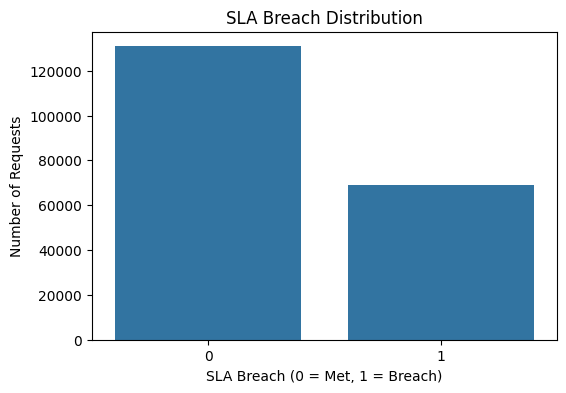

In [26]:
# SLA breach distribution

plt.figure(figsize=(6, 4))

sns.countplot(
    x="SLA_Breach",
    data=df
)

plt.title(
    "SLA Breach Distribution"
)

plt.xlabel(
    "SLA Breach (0 = Met, 1 = Breach)"
)

plt.ylabel(
    "Number of Requests"
)

plt.show()


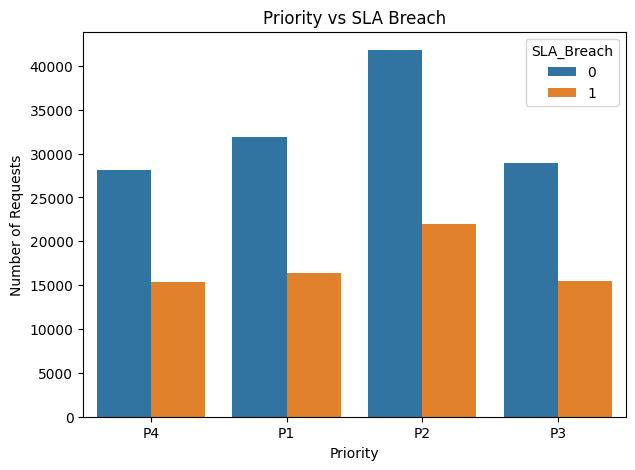

In [27]:
# Priority vs SLA Breach

plt.figure(figsize=(7, 5))

sns.countplot(
    x="Priority",
    hue="SLA_Breach",
    data=df
)

plt.title(
    "Priority vs SLA Breach"
)

plt.xlabel("Priority")

plt.ylabel("Number of Requests")

plt.show()

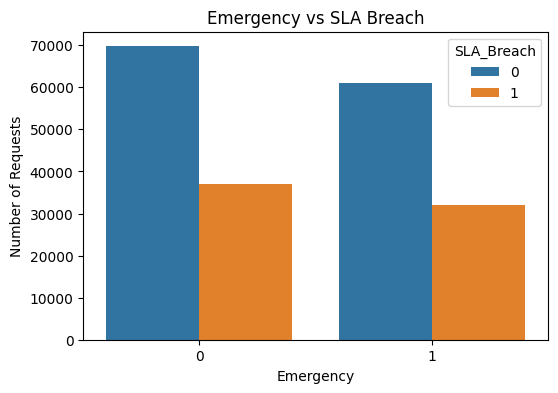

In [28]:
# Emergency vs SLA Breach

plt.figure(figsize=(6, 4))

sns.countplot(
    x="Emergency",
    hue="SLA_Breach",
    data=df
)

plt.title(
    "Emergency vs SLA Breach"
)

plt.xlabel(
    "Emergency"
)

plt.ylabel(
    "Number of Requests"
)

plt.show()

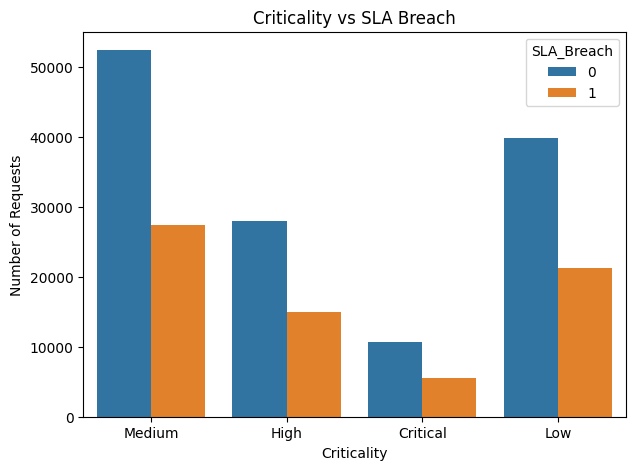

In [29]:
# Criticality vs SLA Breach

plt.figure(figsize=(7, 5))

sns.countplot(
    x="Criticality",
    hue="SLA_Breach",
    data=df
)

plt.title(
    "Criticality vs SLA Breach"
)

plt.xlabel(
    "Criticality"
)

plt.ylabel(
    "Number of Requests"
)

plt.show()

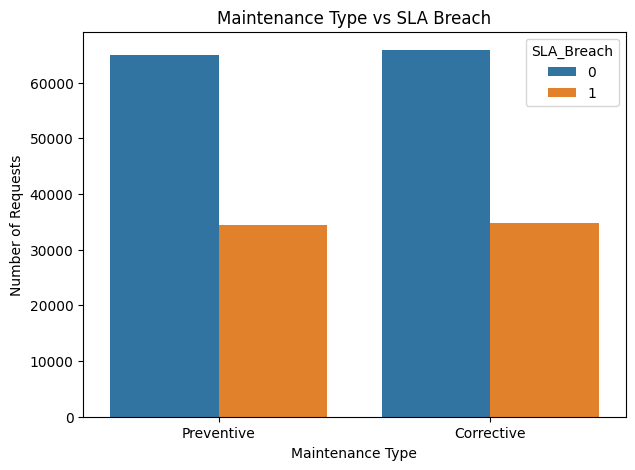

In [30]:
# Maintenance Type vs SLA Breach

plt.figure(figsize=(7, 5))

sns.countplot(
    x="Maintenance_Type",
    hue="SLA_Breach",
    data=df
)

plt.title(
    "Maintenance Type vs SLA Breach"
)

plt.xlabel(
    "Maintenance Type"
)

plt.ylabel(
    "Number of Requests"
)

plt.show()

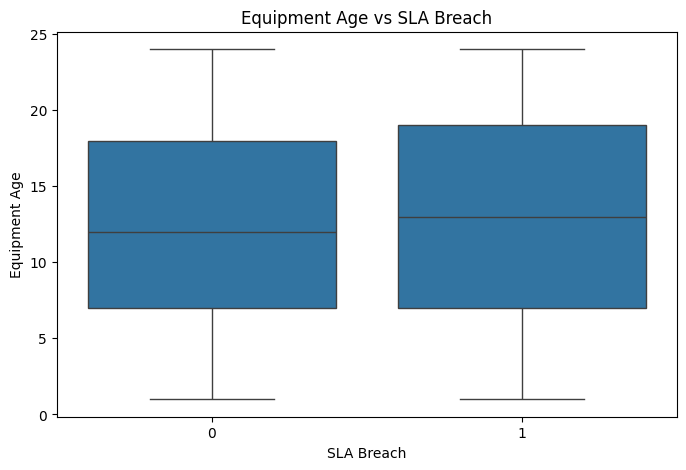

In [31]:
# Equipment age vs SLA breach

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="SLA_Breach",
    y="Equipment_Age",
    data=df
)

plt.title(
    "Equipment Age vs SLA Breach"
)

plt.xlabel(
    "SLA Breach"
)

plt.ylabel(
    "Equipment Age"
)

plt.show()

In [32]:
# Define model features

model_columns = [

    "Year",
    "Month",

    "Building",
    "Department",
    "Asset_Category",
    "Asset_Type",

    "Equipment_Age",
    "Criticality",
    "Complaint_Type",
    "Maintenance_Type",
    "Priority",
    "Emergency",

    "Technician_Trade",
    "Technician_Count",

    "Spare_Required",
    "PTW_Required",

    "Outside_Temperature",
    "Response_Target_Min",
    "Estimated_Cost",

    "Request_Year",
    "Request_Month",
    "Request_Day",
    "Request_DayOfWeek",
    "Request_Weekend",
    "Request_Hour",

    "Equipment_Age_Group"
]

print(
    "Number of model features:",
    len(model_columns)
)

Number of model features: 26


In [33]:
for i, col in enumerate(
    model_columns,
    1
):

    print(
        i,
        ":",
        col
    )

1 : Year
2 : Month
3 : Building
4 : Department
5 : Asset_Category
6 : Asset_Type
7 : Equipment_Age
8 : Criticality
9 : Complaint_Type
10 : Maintenance_Type
11 : Priority
12 : Emergency
13 : Technician_Trade
14 : Technician_Count
15 : Spare_Required
16 : PTW_Required
17 : Outside_Temperature
18 : Response_Target_Min
19 : Estimated_Cost
20 : Request_Year
21 : Request_Month
22 : Request_Day
23 : Request_DayOfWeek
24 : Request_Weekend
25 : Request_Hour
26 : Equipment_Age_Group


In [34]:
# Create input features

X = df[
    model_columns
].copy()

# Create target

y = df[
    "SLA_Breach"
].copy()

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

X shape: (200000, 26)
y shape: (200000,)


In [35]:
print(
    y.value_counts()
)

SLA_Breach
0    130850
1     69150
Name: count, dtype: int64


In [36]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print(
    "Training records:",
    X_train.shape[0]
)

print(
    "Testing records:",
    X_test.shape[0]
)

Training records: 160000
Testing records: 40000


In [37]:
print("Training target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training target:
SLA_Breach
0    104680
1     55320
Name: count, dtype: int64

Testing target:
SLA_Breach
0    26170
1    13830
Name: count, dtype: int64


In [38]:
# Numerical columns

numerical_features = [

    "Year",
    "Month",
    "Equipment_Age",
    "Emergency",
    "Technician_Count",
    "Outside_Temperature",
    "Response_Target_Min",
    "Estimated_Cost",
    "Request_Year",
    "Request_Month",
    "Request_Day",
    "Request_DayOfWeek",
    "Request_Hour"
]


# Categorical columns

categorical_features = [

    "Building",
    "Department",
    "Asset_Category",
    "Asset_Type",
    "Criticality",
    "Complaint_Type",
    "Maintenance_Type",
    "Priority",
    "Technician_Trade",
    "Spare_Required",
    "PTW_Required",
    "Request_Weekend",
    "Equipment_Age_Group"
]


print(
    "Numerical features:",
    len(numerical_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

Numerical features: 13
Categorical features: 13


In [39]:
# Numerical preprocessing

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# Categorical preprocessing

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# Combine both preprocessing methods

preprocessor = ColumnTransformer(
    transformers=[

        (
            "numerical",
            numeric_pipeline,
            numerical_features
        ),

        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print(
    "Preprocessing pipeline created."
)

Preprocessing pipeline created.


In [40]:
# Create Logistic Regression model

logistic_model = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [41]:
# Train Logistic Regression

logistic_model.fit(
    X_train,
    y_train
)

print(
    "Logistic Regression trained successfully."
)

Logistic Regression trained successfully.


In [42]:
# Make predictions

logistic_prediction = (
    logistic_model.predict(
        X_test
    )
)

logistic_probability = (
    logistic_model.predict_proba(
        X_test
    )[:, 1]
)

In [43]:
# Evaluate Logistic Regression

logistic_accuracy = accuracy_score(
    y_test,
    logistic_prediction
)

logistic_precision = precision_score(
    y_test,
    logistic_prediction,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_prediction,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_prediction,
    zero_division=0
)

logistic_auc = roc_auc_score(
    y_test,
    logistic_probability
)


print("Logistic Regression Results")
print("--------------------------------")

print(
    "Accuracy :",
    round(logistic_accuracy, 4)
)

print(
    "Precision:",
    round(logistic_precision, 4)
)

print(
    "Recall   :",
    round(logistic_recall, 4)
)

print(
    "F1 Score :",
    round(logistic_f1, 4)
)

print(
    "ROC-AUC  :",
    round(logistic_auc, 4)
)

Logistic Regression Results
--------------------------------
Accuracy : 0.5048
Precision: 0.3477
Recall   : 0.4933
F1 Score : 0.4079
ROC-AUC  : 0.5027


In [44]:
print(
    classification_report(
        y_test,
        logistic_prediction,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.66      0.51      0.57     26170
           1       0.35      0.49      0.41     13830

    accuracy                           0.50     40000
   macro avg       0.50      0.50      0.49     40000
weighted avg       0.55      0.50      0.52     40000



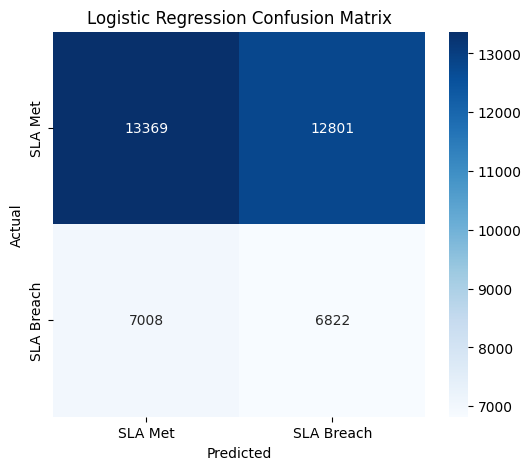

In [45]:
# Confusion matrix for Logistic Regression

cm = confusion_matrix(
    y_test,
    logistic_prediction
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "SLA Met",
        "SLA Breach"
    ],
    yticklabels=[
        "SLA Met",
        "SLA Breach"
    ]
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [46]:
# Create Random Forest model

random_forest_model = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            RandomForestClassifier(

                n_estimators=300,

                max_depth=12,

                min_samples_split=10,

                min_samples_leaf=2,

                class_weight="balanced",

                random_state=42,

                n_jobs=-1
            )
        )
    ]
)

In [47]:
# Train Random Forest

random_forest_model.fit(
    X_train,
    y_train
)

print(
    "Random Forest trained successfully."
)

Random Forest trained successfully.


In [48]:
# Make predictions

rf_prediction = (
    random_forest_model.predict(
        X_test
    )
)

rf_probability = (
    random_forest_model.predict_proba(
        X_test
    )[:, 1]
)

In [49]:
# Evaluate Random Forest

rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)

rf_precision = precision_score(
    y_test,
    rf_prediction,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_prediction,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_prediction,
    zero_division=0
)

rf_auc = roc_auc_score(
    y_test,
    rf_probability
)


print("Random Forest Results")
print("--------------------------------")

print(
    "Accuracy :",
    round(rf_accuracy, 4)
)

print(
    "Precision:",
    round(rf_precision, 4)
)

print(
    "Recall   :",
    round(rf_recall, 4)
)

print(
    "F1 Score :",
    round(rf_f1, 4)
)

print(
    "ROC-AUC  :",
    round(rf_auc, 4)
)

Random Forest Results
--------------------------------
Accuracy : 0.5531
Precision: 0.3437
Recall   : 0.3219
F1 Score : 0.3325
ROC-AUC  : 0.4993


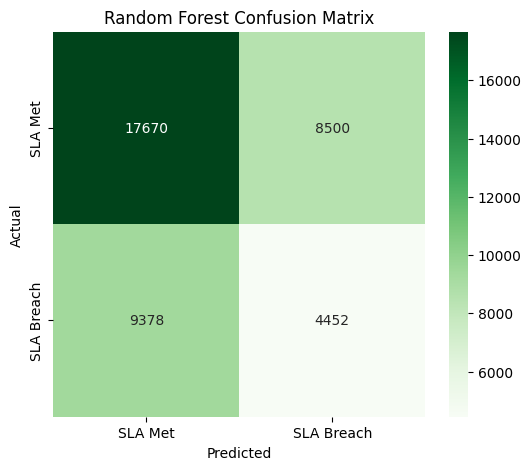

In [50]:
# Confusion matrix for Random Forest

cm = confusion_matrix(
    y_test,
    rf_prediction
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=[
        "SLA Met",
        "SLA Breach"
    ],
    yticklabels=[
        "SLA Met",
        "SLA Breach"
    ]
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [51]:
# Compare both models

model_comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],

    "Precision": [
        logistic_precision,
        rf_precision
    ],

    "Recall": [
        logistic_recall,
        rf_recall
    ],

    "F1 Score": [
        logistic_f1,
        rf_f1
    ],

    "ROC-AUC": [
        logistic_auc,
        rf_auc
    ]
})

display(
    model_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.5048,0.3477,0.4933,0.4079,0.5027
1,Random Forest,0.5530,0.3437,0.3219,0.3325,0.4993


ROC CURVE COMPARISON


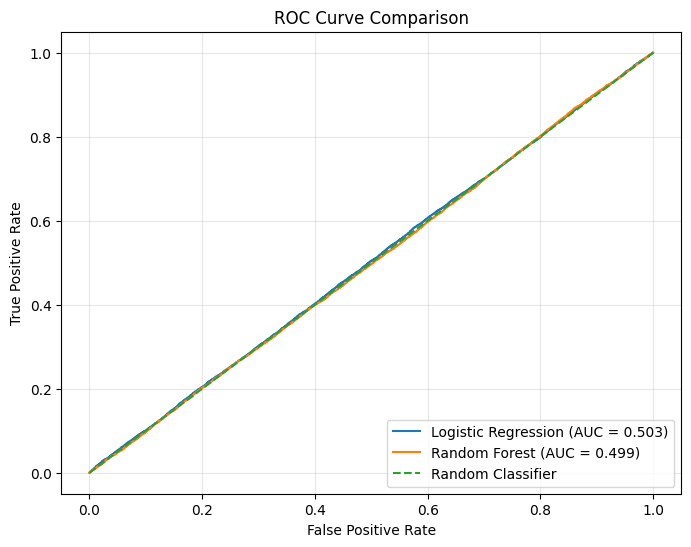


ROC-AUC Results
----------------------------------------
Logistic Regression ROC-AUC: 0.5027
Random Forest ROC-AUC: 0.4993


In [52]:
# Compare ROC curves

# ============================================================
# MODULE 25 — ROC CURVE COMPARISON
# ============================================================

from sklearn.metrics import roc_curve, auc

print("=" * 60)
print("ROC CURVE COMPARISON")
print("=" * 60)

# Calculate ROC values for Logistic Regression

logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_probability
)

logistic_roc_auc = auc(
    logistic_fpr,
    logistic_tpr
)


# Calculate ROC values for Random Forest

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_probability
)

rf_roc_auc = auc(
    rf_fpr,
    rf_tpr
)


# Plot ROC curves

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {logistic_roc_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

# Random classifier reference line

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve Comparison"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.3
)

plt.show()


print("\nROC-AUC Results")
print("-" * 40)

print(
    "Logistic Regression ROC-AUC:",
    round(logistic_roc_auc, 4)
)

print(
    "Random Forest ROC-AUC:",
    round(rf_roc_auc, 4)
)

In [53]:
# Select the model with better ROC-AUC

if rf_auc > logistic_auc:

    final_model = random_forest_model
    final_model_name = "Random Forest"

    final_prediction = rf_prediction
    final_probability = rf_probability

else:

    final_model = logistic_model
    final_model_name = "Logistic Regression"

    final_prediction = logistic_prediction
    final_probability = logistic_probability


print(
    "Final model selected:",
    final_model_name
)

Final model selected: Logistic Regression


In [54]:
# Final model performance

final_accuracy = accuracy_score(
    y_test,
    final_prediction
)

final_precision = precision_score(
    y_test,
    final_prediction,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_prediction,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_prediction,
    zero_division=0
)

final_auc = roc_auc_score(
    y_test,
    final_probability
)


print("--------------------------------")
print("FINAL MODEL PERFORMANCE")
print("--------------------------------")

print(
    "Model:",
    final_model_name
)

print(
    "Accuracy:",
    round(final_accuracy, 4)
)

print(
    "Precision:",
    round(final_precision, 4)
)

print(
    "Recall:",
    round(final_recall, 4)
)

print(
    "F1 Score:",
    round(final_f1, 4)
)

print(
    "ROC-AUC:",
    round(final_auc, 4)
)

--------------------------------
FINAL MODEL PERFORMANCE
--------------------------------
Model: Logistic Regression
Accuracy: 0.5048
Precision: 0.3477
Recall: 0.4933
F1 Score: 0.4079
ROC-AUC: 0.5027


In [55]:
# Check prediction probability distribution

print(
    "Minimum:",
    round(final_probability.min(), 4)
)

print(
    "Maximum:",
    round(final_probability.max(), 4)
)

print(
    "Mean:",
    round(final_probability.mean(), 4)
)

print(
    "Median:",
    round(
        np.median(final_probability),
        4
    )
)

print(
    "Standard deviation:",
    round(
        final_probability.std(),
        4
    )
)

Minimum: 0.4415
Maximum: 0.5628
Mean: 0.4998
Median: 0.4996
Standard deviation: 0.0156


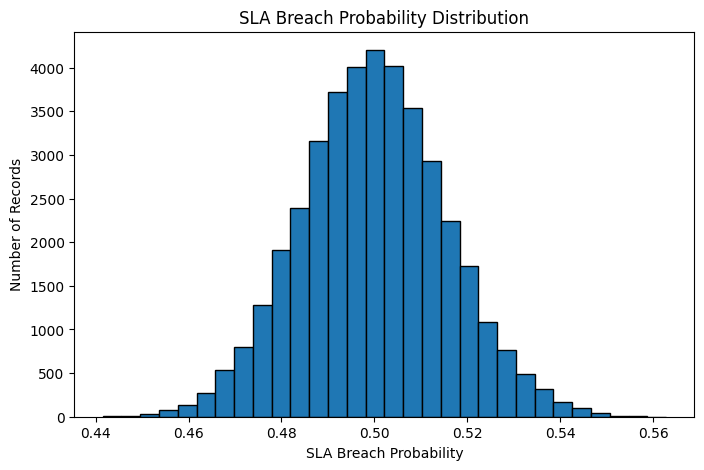

In [56]:
# Plot probability distribution

plt.figure(figsize=(8, 5))

plt.hist(
    final_probability,
    bins=30,
    edgecolor="black"
)

plt.xlabel(
    "SLA Breach Probability"
)

plt.ylabel(
    "Number of Records"
)

plt.title(
    "SLA Breach Probability Distribution"
)

plt.show()

In [57]:
# Display Random Forest feature importance

if final_model_name == "Random Forest":

    preprocessor_final = (
        final_model.named_steps[
            "preprocessor"
        ]
    )

    classifier_final = (
        final_model.named_steps[
            "classifier"
        ]
    )

    feature_names = (
        preprocessor_final
        .get_feature_names_out()
    )

    importance_values = (
        classifier_final
        .feature_importances_
    )

    importance_df = pd.DataFrame({

        "Feature": feature_names,

        "Importance": importance_values

    })

    importance_df = (
        importance_df
        .sort_values(
            "Importance",
            ascending=False
        )
    )

    display(
        importance_df.head(20)
    )

    plt.figure(figsize=(10, 7))

    top_features = (
        importance_df
        .head(20)
        .sort_values(
            "Importance"
        )
    )

    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )

    plt.title(
        "Top 20 Features Affecting SLA Prediction"
    )

    plt.xlabel(
        "Importance"
    )

    plt.show()

else:

    print(
        "Random Forest was not selected."
    )

Random Forest was not selected.


In [58]:
# Select one real test record

sample_index = X_test.index[0]

sample = X_test.loc[
    [sample_index]
]

actual_sla = y_test.loc[
    sample_index
]

prediction = final_model.predict(
    sample
)[0]

probability = final_model.predict_proba(
    sample
)[0, 1]


print("--------------------------------")
print("REAL RECORD TEST")
print("--------------------------------")

print(
    "Actual SLA:",
    "SLA BREACH"
    if actual_sla == 1
    else "SLA MET"
)

print(
    "Model Prediction:",
    "SLA BREACH"
    if prediction == 1
    else "SLA MET"
)

print(
    "Breach Probability:",
    f"{probability * 100:.2f}%"
)

--------------------------------
REAL RECORD TEST
--------------------------------
Actual SLA: SLA BREACH
Model Prediction: SLA BREACH
Breach Probability: 52.54%


In [59]:
# Test the same request with different priorities

test_record = X_test.iloc[
    [0]
].copy()

priority_results = []

for priority in [
    "P1",
    "P2",
    "P3",
    "P4"
]:

    record = test_record.copy()

    record["Priority"] = priority

    prediction = final_model.predict(
        record
    )[0]

    probability = final_model.predict_proba(
        record
    )[0, 1]

    priority_results.append({

        "Priority": priority,

        "Prediction":
            "SLA BREACH"
            if prediction == 1
            else "SLA MET",

        "Breach Probability":
            round(
                probability * 100,
                2
            )
    })


priority_results = pd.DataFrame(
    priority_results
)

display(
    priority_results
)

,Priority,Prediction,Breach Probability
0,P1,SLA BREACH,52.12
1,P2,SLA BREACH,52.50
2,P3,SLA BREACH,52.76
3,P4,SLA BREACH,52.54


In [60]:
# Save the trained model

model_file = (
    "cmms_sla_risk_model.pkl"
)

columns_file = (
    "cmms_model_columns.pkl"
)

joblib.dump(
    final_model,
    model_file
)

joblib.dump(
    model_columns,
    columns_file
)

print(
    "Model saved successfully."
)

print(
    model_file
)

print(
    columns_file
)

Model saved successfully.
cmms_sla_risk_model.pkl
cmms_model_columns.pkl


In [61]:
# Load the saved model again

loaded_model = joblib.load(
    model_file
)

loaded_columns = joblib.load(
    columns_file
)

print(
    "Saved model loaded successfully."
)

print(
    "Model type:",
    type(loaded_model)
)

print(
    "Number of features:",
    len(loaded_columns)
)

Saved model loaded successfully.
Model type: <class 'sklearn.pipeline.Pipeline'>
Number of features: 26


In [62]:
# Display saved model columns

for i, col in enumerate(
    loaded_columns,
    1
):

    print(
        i,
        ":",
        col
    )

1 : Year
2 : Month
3 : Building
4 : Department
5 : Asset_Category
6 : Asset_Type
7 : Equipment_Age
8 : Criticality
9 : Complaint_Type
10 : Maintenance_Type
11 : Priority
12 : Emergency
13 : Technician_Trade
14 : Technician_Count
15 : Spare_Required
16 : PTW_Required
17 : Outside_Temperature
18 : Response_Target_Min
19 : Estimated_Cost
20 : Request_Year
21 : Request_Month
22 : Request_Day
23 : Request_DayOfWeek
24 : Request_Weekend
25 : Request_Hour
26 : Equipment_Age_Group


In [63]:
# Test the actual saved model

test_prediction = loaded_model.predict(
    X_test.iloc[[0]]
)[0]

test_probability = loaded_model.predict_proba(
    X_test.iloc[[0]]
)[0, 1]

print(
    "Prediction:",
    "SLA BREACH"
    if test_prediction == 1
    else "SLA MET"
)

print(
    "Breach Probability:",
    f"{test_probability * 100:.2f}%"
)

Prediction: SLA BREACH
Breach Probability: 52.54%


In [65]:
# ============================================================
# MODULE 34 — CHECK AND DOWNLOAD MODEL FILES
# ============================================================

import os

print("=" * 60)
print("CHECKING SAVED MODEL FILES")
print("=" * 60)

model_file = "cmms_sla_risk_model.pkl"
columns_file = "cmms_model_columns.pkl"


# Check model file

if os.path.exists(model_file):

    print(
        "✅ Model file found:",
        model_file
    )

else:

    print(
        "❌ Model file NOT found:",
        model_file
    )


# Check columns file

if os.path.exists(columns_file):

    print(
        "✅ Columns file found:",
        columns_file
    )

else:

    print(
        "❌ Columns file NOT found:",
        columns_file
    )

CHECKING SAVED MODEL FILES
✅ Model file found: cmms_sla_risk_model.pkl
✅ Columns file found: cmms_model_columns.pkl


In [69]:
from google.colab import files

files.download(
    "cmms_sla_risk_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:
files.download(
    "cmms_model_columns.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [68]:
print("=" * 60)
print("CMMS SLA BREACH PREDICTION - FINAL RESULT")
print("=" * 60)

print(
    "Final Model:",
    final_model_name
)

print(
    "Accuracy:",
    round(final_accuracy, 4)
)

print(
    "Precision:",
    round(final_precision, 4)
)

print(
    "Recall:",
    round(final_recall, 4)
)

print(
    "F1 Score:",
    round(final_f1, 4)
)

print(
    "ROC-AUC:",
    round(final_auc, 4)
)

print(
    "\nModel files created:"
)

print(
    "- cmms_sla_risk_model.pkl"
)

print(
    "- cmms_model_columns.pkl"
)

CMMS SLA BREACH PREDICTION - FINAL RESULT
Final Model: Logistic Regression
Accuracy: 0.5048
Precision: 0.3477
Recall: 0.4933
F1 Score: 0.4079
ROC-AUC: 0.5027

Model files created:
- cmms_sla_risk_model.pkl
- cmms_model_columns.pkl


In [71]:
# ============================================================
# FINAL MODEL VALIDATION
# ============================================================

import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("=" * 70)
print("FINAL SAVED MODEL VALIDATION")
print("=" * 70)


# ------------------------------------------------------------
# 1. LOAD SAVED MODEL
# ------------------------------------------------------------

final_model = joblib.load(
    "cmms_sla_risk_model.pkl"
)

print("\nModel loaded successfully.")
print("Model type:", type(final_model))


# ------------------------------------------------------------
# 2. CHECK TEST DATA
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TEST DATA CHECK")
print("=" * 70)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print(
    "Target values:",
    sorted(y_test.unique())
)


# ------------------------------------------------------------
# 3. PREDICTION
# ------------------------------------------------------------

final_prediction = final_model.predict(
    X_test
)


# ------------------------------------------------------------
# 4. PROBABILITY
# ------------------------------------------------------------

final_probability = final_model.predict_proba(
    X_test
)[:, 1]


# ------------------------------------------------------------
# 5. PERFORMANCE METRICS
# ------------------------------------------------------------

final_accuracy = accuracy_score(
    y_test,
    final_prediction
)

final_precision = precision_score(
    y_test,
    final_prediction,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_prediction,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_prediction,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    final_probability
)


# ------------------------------------------------------------
# 6. DISPLAY RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL MODEL PERFORMANCE")
print("=" * 70)

print(
    f"\nAccuracy  : {final_accuracy:.4f}"
)

print(
    f"Precision : {final_precision:.4f}"
)

print(
    f"Recall    : {final_recall:.4f}"
)

print(
    f"F1 Score  : {final_f1:.4f}"
)

print(
    f"ROC-AUC   : {final_roc_auc:.4f}"
)


# ------------------------------------------------------------
# 7. CONFUSION MATRIX
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

cm = confusion_matrix(
    y_test,
    final_prediction
)

print(cm)


# ------------------------------------------------------------
# 8. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        final_prediction,
        zero_division=0
    )
)


# ------------------------------------------------------------
# 9. PROBABILITY CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BREACH PROBABILITY CHECK")
print("=" * 70)

print(
    f"Minimum : {final_probability.min():.4f}"
)

print(
    f"Maximum : {final_probability.max():.4f}"
)

print(
    f"Mean    : {final_probability.mean():.4f}"
)

print(
    f"Median  : {np.median(final_probability):.4f}"
)

print(
    f"Std Dev : {final_probability.std():.4f}"
)


# ------------------------------------------------------------
# 10. PREDICTION DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PREDICTION DISTRIBUTION")
print("=" * 70)

print(
    pd.Series(final_prediction)
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 11. ACTUAL TARGET DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ACTUAL TARGET DISTRIBUTION")
print("=" * 70)

print(
    y_test.value_counts()
    .sort_index()
)


print("\n" + "=" * 70)
print("FINAL VALIDATION COMPLETED")
print("=" * 70)

FINAL SAVED MODEL VALIDATION

Model loaded successfully.
Model type: <class 'sklearn.pipeline.Pipeline'>

TEST DATA CHECK
X_test shape: (40000, 26)
y_test shape: (40000,)
Target values: [np.int64(0), np.int64(1)]

FINAL MODEL PERFORMANCE

Accuracy  : 0.5048
Precision : 0.3477
Recall    : 0.4933
F1 Score  : 0.4079
ROC-AUC   : 0.5027

CONFUSION MATRIX
[[13369 12801]
 [ 7008  6822]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.66      0.51      0.57     26170
           1       0.35      0.49      0.41     13830

    accuracy                           0.50     40000
   macro avg       0.50      0.50      0.49     40000
weighted avg       0.55      0.50      0.52     40000


BREACH PROBABILITY CHECK
Minimum : 0.4415
Maximum : 0.5628
Mean    : 0.4998
Median  : 0.4996
Std Dev : 0.0156

PREDICTION DISTRIBUTION
0    20377
1    19623
Name: count, dtype: int64

ACTUAL TARGET DISTRIBUTION
SLA_Breach
0    26170
1    13830
Name: count, dtype: in

In [73]:
# ============================================================
# FINAL MODEL — FEATURE IMPORTANCE / COEFFICIENT ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("FINAL MODEL FEATURE ANALYSIS")
print("=" * 70)


# ------------------------------------------------------------
# GET MODEL STEPS
# ------------------------------------------------------------

preprocessor = final_model.named_steps["preprocessor"]

classifier = final_model.named_steps["classifier"]


print("\nFinal classifier:")
print(classifier)


# ------------------------------------------------------------
# GET TRANSFORMED FEATURE NAMES
# ------------------------------------------------------------

feature_names = (
    preprocessor
    .get_feature_names_out()
)


print(
    "\nNumber of transformed features:",
    len(feature_names)
)


# ------------------------------------------------------------
# CHECK MODEL TYPE
# ------------------------------------------------------------

if hasattr(
    classifier,
    "coef_"
):

    print(
        "\nModel type: Logistic Regression"
    )

    coefficients = (
        classifier.coef_[0]
    )

    feature_df = pd.DataFrame({

        "Feature":
            feature_names,

        "Coefficient":
            coefficients,

        "Absolute_Coefficient":
            np.abs(coefficients)

    })

    # Sort by absolute coefficient

    feature_df = feature_df.sort_values(
        "Absolute_Coefficient",
        ascending=False
    )

    print("\nTop 30 influential features:")
    print("=" * 70)

    print(
        feature_df.head(30).to_string(
            index=False
        )
    )


else:

    print(
        "\nThis model does not have Logistic Regression coefficients."
    )

    print(
        "Checking for Random Forest feature importance..."
    )

    if hasattr(
        classifier,
        "feature_importances_"
    ):

        importance = (
            classifier.feature_importances_
        )

        feature_df = pd.DataFrame({

            "Feature":
                feature_names,

            "Importance":
                importance

        })

        feature_df = feature_df.sort_values(
            "Importance",
            ascending=False
        )

        print(
            feature_df.head(30).to_string(
                index=False
            )
        )

    else:

        print(
            "Feature importance is not available."
        )

FINAL MODEL FEATURE ANALYSIS

Final classifier:
LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

Number of transformed features: 166

Model type: Logistic Regression

Top 30 influential features:
                                            Feature  Coefficient  Absolute_Coefficient
          categorical__Complaint_Type_Paint Peeling    -0.131064              0.131064
     categorical__Complaint_Type_Earth Leakage Trip    -0.113262              0.113262
           categorical__Complaint_Type_Chair Broken     0.102015              0.102015
categorical__Complaint_Type_Condenser Fan Defective     0.101275              0.101275
           categorical__Complaint_Type_Power Outage     0.094892              0.094892
     categorical__Complaint_Type_Output Voltage Low     0.090074              0.090074
           categorical__Complaint_Type_Seal Failure    -0.089120              0.089120
       categorical__Complaint_Type_Thermostat Fault    -0.085769              0.

In [74]:
# ============================================================
# FINAL MODEL COMPARISON
# LOGISTIC REGRESSION vs RANDOM FOREST
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)


# ============================================================
# 1. LOGISTIC REGRESSION RESULTS
# ============================================================

print("\nCalculating Logistic Regression results...")

logistic_prediction = final_model.predict(X_test)

logistic_probability = final_model.predict_proba(
    X_test
)[:, 1]


logistic_accuracy = accuracy_score(
    y_test,
    logistic_prediction
)

logistic_precision = precision_score(
    y_test,
    logistic_prediction,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_prediction,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_prediction,
    zero_division=0
)

logistic_auc = roc_auc_score(
    y_test,
    logistic_probability
)


# ============================================================
# 2. GET PREPROCESSOR
# ============================================================

preprocessor = final_model.named_steps[
    "preprocessor"
]


# ============================================================
# 3. TRANSFORM TRAINING AND TEST DATA
# ============================================================

print("\nTransforming data for Random Forest...")

X_train_transformed = preprocessor.transform(
    X_train
)

X_test_transformed = preprocessor.transform(
    X_test
)

print(
    "Training data shape:",
    X_train_transformed.shape
)

print(
    "Test data shape:",
    X_test_transformed.shape
)


# ============================================================
# 4. TRAIN RANDOM FOREST
# ============================================================

print("\nTraining Random Forest...")

rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_final.fit(
    X_train_transformed,
    y_train
)


# ============================================================
# 5. RANDOM FOREST PREDICTION
# ============================================================

rf_prediction = rf_final.predict(
    X_test_transformed
)

rf_probability = rf_final.predict_proba(
    X_test_transformed
)[:, 1]


# ============================================================
# 6. RANDOM FOREST METRICS
# ============================================================

rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)

rf_precision = precision_score(
    y_test,
    rf_prediction,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_prediction,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_prediction,
    zero_division=0
)

rf_auc = roc_auc_score(
    y_test,
    rf_probability
)


# ============================================================
# 7. COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],

    "Precision": [
        logistic_precision,
        rf_precision
    ],

    "Recall": [
        logistic_recall,
        rf_recall
    ],

    "F1 Score": [
        logistic_f1,
        rf_f1
    ],

    "ROC-AUC": [
        logistic_auc,
        rf_auc
    ]

})


print("\n")
print("=" * 70)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)

print(
    comparison.round(4).to_string(
        index=False
    )
)


# ============================================================
# 8. BEST MODEL
# ============================================================

best_model_index = comparison[
    "ROC-AUC"
].idxmax()

best_model_name = comparison.loc[
    best_model_index,
    "Model"
]

best_auc = comparison.loc[
    best_model_index,
    "ROC-AUC"
]

print("\n" + "=" * 70)
print("BEST MODEL BASED ON ROC-AUC")
print("=" * 70)

print(
    "Model:",
    best_model_name
)

print(
    f"ROC-AUC: {best_auc:.4f}"
)

FINAL MODEL COMPARISON

Calculating Logistic Regression results...

Transforming data for Random Forest...
Training data shape: (160000, 166)
Test data shape: (40000, 166)

Training Random Forest...


MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.5048     0.3477  0.4933    0.4079   0.5027
      Random Forest    0.5234     0.3445  0.4194    0.3783   0.4994

BEST MODEL BASED ON ROC-AUC
Model: Logistic Regression
ROC-AUC: 0.5027


In [75]:
# ============================================================
# SAVE FINAL LOGISTIC REGRESSION MODEL
# ============================================================

import joblib
import os

print("=" * 70)
print("SAVING FINAL MODEL")
print("=" * 70)


# ------------------------------------------------------------
# SAVE MODEL
# ------------------------------------------------------------

joblib.dump(
    final_model,
    "cmms_sla_risk_model.pkl"
)


# ------------------------------------------------------------
# SAVE MODEL COLUMNS
# ------------------------------------------------------------

joblib.dump(
    list(X_train.columns),
    "cmms_model_columns.pkl"
)


# ------------------------------------------------------------
# VERIFY FILES
# ------------------------------------------------------------

print("\nModel file exists:")

print(
    os.path.exists(
        "cmms_sla_risk_model.pkl"
    )
)


print("\nColumns file exists:")

print(
    os.path.exists(
        "cmms_model_columns.pkl"
    )
)


# ------------------------------------------------------------
# FILE SIZE
# ------------------------------------------------------------

print("\nModel file size:")

print(
    os.path.getsize(
        "cmms_sla_risk_model.pkl"
    ),
    "bytes"
)


print("\nColumns file size:")

print(
    os.path.getsize(
        "cmms_model_columns.pkl"
    ),
    "bytes"
)


print("\n" + "=" * 70)
print("FINAL MODEL SAVED SUCCESSFULLY")
print("=" * 70)

SAVING FINAL MODEL

Model file exists:
True

Columns file exists:
True

Model file size:
12250 bytes

Columns file size:
425 bytes

FINAL MODEL SAVED SUCCESSFULLY
